Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


PROJECT PATH

In [2]:
PROJECT_PATH = "/content/drive/MyDrive/Deep-Learning-for-Predictive-Maintenance"

import os

os.makedirs(
    f"{PROJECT_PATH}/results/figures",
    exist_ok=True
)

os.makedirs(
    f"{PROJECT_PATH}/results/metrics",
    exist_ok=True
)

os.makedirs(
    f"{PROJECT_PATH}/results/models",
    exist_ok=True
)

print("Folders ready.")

Folders ready.


Clone Repository

In [3]:
!git clone https://github.com/shefiramarizcha62-sudo/Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-.git

Cloning into 'Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-'...
remote: Enumerating objects: 182, done.
remote: Counting objects: 100% (182/182), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 182 (delta 65), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (182/182), 4.09 MiB | 8.51 MiB/s, done.
Resolving deltas: 100% (65/65), done.


Masuk ke Folder Project

In [4]:
%cd Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-

/content/Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-


Cek Isi Folder

In [5]:
ls

data/  docs/  notebooks/  README.md  requirements.txt  results/  src/


Import Library

In [6]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

Load Dataset

In [7]:
columns = ['unit_number','time_in_cycles',
           'op_setting_1','op_setting_2','op_setting_3']

sensor_columns = [f'sensor_{i}' for i in range(1,22)]

columns.extend(sensor_columns)

train_df = pd.read_csv(
    'data/train_FD001.txt',
    sep='\s+',
    header=None
)

train_df = train_df.iloc[:,:26]

train_df.columns = columns

train_df.head()

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_584/2593744736.py:10: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Hitung RUL

In [8]:
rul = train_df.groupby('unit_number')['time_in_cycles'].max()

train_df = train_df.merge(
    rul.to_frame(name='max_cycle'),
    on='unit_number'
)

train_df['RUL'] = (
    train_df['max_cycle']
    - train_df['time_in_cycles']
)

Piece-wise RUL

In [9]:
max_rul = 125

train_df['RUL'] = train_df['RUL'].clip(upper=max_rul)

Feature Selection

In [10]:
sensor_cols = sensor_columns

train_df[sensor_cols].std().sort_values()

,0
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_16,1.556432e-14
sensor_10,4.660829e-13
sensor_5,3.394700e-12
sensor_1,6.537152e-11
sensor_6,1.388985e-03
sensor_15,3.750504e-02
sensor_8,7.098548e-02
sensor_13,7.191892e-02


In [11]:
drop_sensors = [
    'sensor_1',
    'sensor_5',
    'sensor_10',
    'sensor_16',
    'sensor_18',
    'sensor_19'
]

train_df = train_df.drop(columns=drop_sensors)

Normalization

In [12]:
features = train_df.columns.difference([
    'unit_number',
    'time_in_cycles',
    'RUL',
    'max_cycle'
])

scaler = MinMaxScaler()

train_df[features] = scaler.fit_transform(
    train_df[features]
)

Denoising

In [13]:
train_df['sensor_2_smooth'] = (
    train_df.groupby('unit_number')['sensor_2']
    .transform(lambda x: x.rolling(5).mean())
)

In [14]:
train_df = train_df.fillna(method='bfill')

/tmp/ipykernel_584/1550443520.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df = train_df.fillna(method='bfill')


VISUALISASI BEFORE/AFTER SMOOTHING

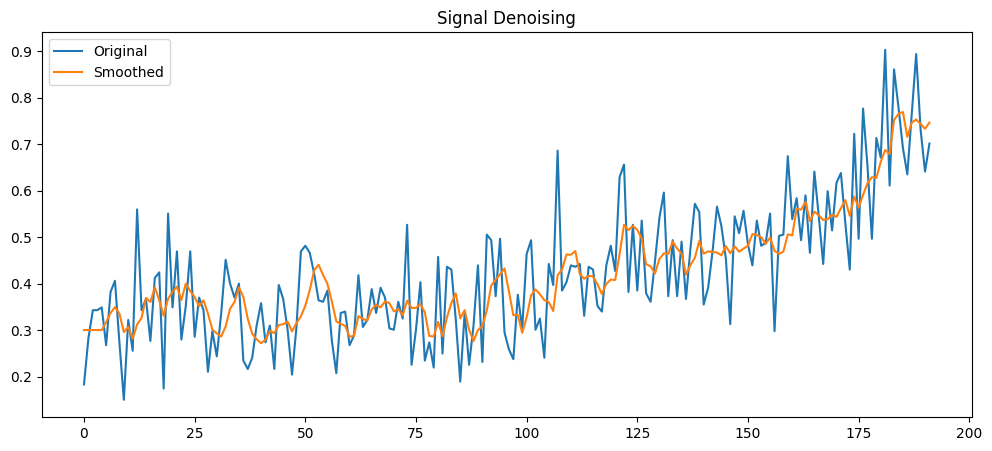

In [15]:
engine_1 = train_df[train_df['unit_number']==1]

plt.figure(figsize=(12,5))

plt.plot(engine_1['sensor_2'], label='Original')
plt.plot(engine_1['sensor_2_smooth'], label='Smoothed')

plt.legend()
plt.title('Signal Denoising')
plt.show()

Sequence Generation

Sequence Length

In [16]:
sequence_length = 30

Function

In [17]:
def create_sequences(data, seq_length, feature_cols):

    X = []
    y = []

    for unit in data['unit_number'].unique():

        unit_df = data[data['unit_number']==unit].copy()

        for i in range(len(unit_df)-seq_length):

            seq_x = unit_df[feature_cols].iloc[
                i:i+seq_length
            ].values

            seq_y = unit_df['RUL'].iloc[
                i+seq_length
            ]

            X.append(seq_x)
            y.append(seq_y)

    return np.array(X), np.array(y)

Generate Sequence

In [18]:
feature_cols = features.tolist()

X_train, y_train = create_sequences(
    train_df,
    sequence_length,
    feature_cols
)

print(X_train.shape)
print(y_train.shape)

(17631, 30, 18)
(17631,)


Save Hasil

In [19]:
np.save('data/X_train.npy', X_train)
np.save('data/y_train.npy', y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (17631, 30, 18)
y_train shape: (17631,)


# BASELINE 1D-CNN

TRAIN VALIDATION SPLIT

In [20]:
from sklearn.model_selection import train_test_split

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

MODEL COMPARISON ANALYSIS

In [21]:
import os

os.makedirs(
    'results/figures',
    exist_ok=True
)

os.makedirs(
    'results/metrics',
    exist_ok=True
)

print("Folders created successfully.")

Folders created successfully.


COMPARISON TABLE

In [22]:
import pandas as pd

comparison = pd.DataFrame({

    'Model': [
        '1D-CNN',
        'CNN-LSTM',
        'Transformer'
    ],

    'RMSE': [
        14.46,
        13.24,
        16.54
    ],

    'MAE': [
        11.00,
        9.68,
        12.10
    ]
})

comparison

,Model,RMSE,MAE
0,1D-CNN,14.46,11.00
1,CNN-LSTM,13.24,9.68
2,Transformer,16.54,12.10


RMSE COMPARISON

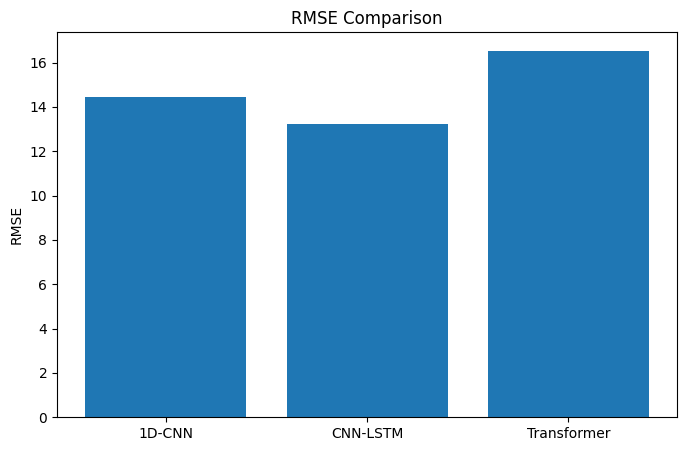

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['RMSE']
)

plt.title(
    'RMSE Comparison'
)

plt.ylabel(
    'RMSE'
)

plt.savefig(
    'results/figures/model_rmse_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

MAE COMPARISON

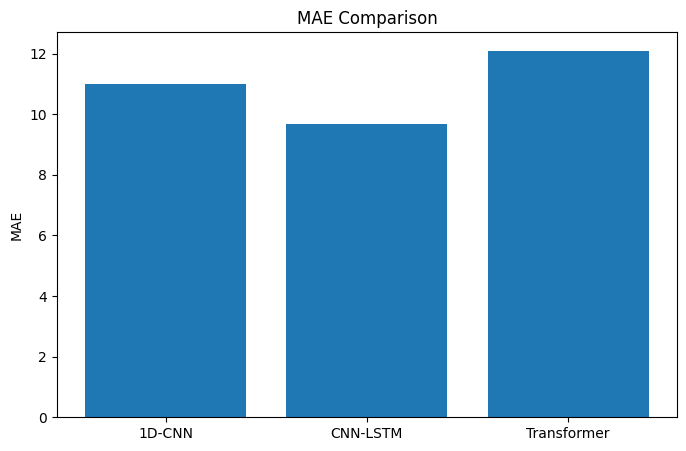

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['MAE']
)

plt.title(
    'MAE Comparison'
)

plt.ylabel(
    'MAE'
)

plt.savefig(
    'results/figures/model_mae_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

BEST MODEL ANALYSIS

In [25]:
best_model = comparison.loc[
    comparison['RMSE'].idxmin()
]

print(
    "Best Model:",
    best_model['Model']
)

print(
    "RMSE:",
    best_model['RMSE']
)

print(
    "MAE:",
    best_model['MAE']
)

Best Model: CNN-LSTM
RMSE: 13.24
MAE: 9.68


SAVE COMPARISON RESULTS

In [26]:
with open(
    'results/metrics/model_comparison.txt',
    'w'
) as f:

    f.write(
        comparison.to_string(index=False)
    )

print(
    "Comparison results saved successfully."
)

Comparison results saved successfully.
